# 2 Qubit Search

# Project 6: Grover's Search (2-Qubit)

**Objective:** Use Amplitude Amplification to search an unstructured database of 4 items and find the target state `11` with near 100% probability in exactly one query.

**Theory:**
Classically, searching an unstructured list of $N$ items requires testing them one by one. On average, it takes $N/2$ guesses (and $N$ guesses in the worst case). For our 2-qubit system, $N = 4$ (states `00`, `01`, `10`, `11`), so it takes an average of 2.25 classical guesses to find a specific item.

Grover's algorithm achieves this in exactly **one query** using quantum interference. It operates in two phases:
1.  **The Oracle (Phase Inversion):** The Oracle identifies the target state and flips its phase (multiplies its amplitude by -1).
2.  **The Diffuser (Inversion About the Average):** The Diffuser takes the state with the flipped phase and magnifies its probability, simultaneously shrinking the probability of all non-target states.

By executing the Oracle and Diffuser sequentially, the target state's probability approaches 100%.

In [1]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from IPython.display import display
import numpy as np

print("Environment Ready.")

Environment Ready.


## Step 1: The Oracle

Our target state is `11`. We need to design an Oracle that flips the phase of *only* the $|11\rangle$ state, leaving all other states (`00`, `01`, `10`) untouched.

Instead of using an ancilla qubit (like we did in the Bernstein-Vazirani algorithm), we can achieve this directly using a **Controlled-Z (CZ)** gate. 

A `Z` gate flips the phase of the $|1\rangle$ state. A `CZ` gate applies a `Z` to the target qubit *only if* the control qubit is also `1`. Therefore, it only flips the phase when both qubits are `1`, successfully tagging our target state $|11\rangle$ with a negative phase.

Oracle Circuit:


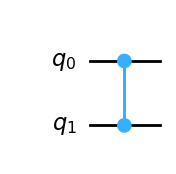

In [2]:
def grover_oracle_11() -> QuantumCircuit:
    """An oracle that flips the phase of the |11> state."""
    qc = QuantumCircuit(2, name="Oracle (11)")
    
    # The Controlled-Z gate flips the phase of |11>
    qc.cz(0, 1)
    
    return qc

# Visualize the Oracle
print("Oracle Circuit:")
display(grover_oracle_11().draw('mpl'))

## Step 2: The Diffuser (Amplitude Amplification)

The Diffuser performs the "Inversion About the Average". It calculates the average amplitude of all states and then reflects each state's amplitude across that average line. Because the Oracle flipped the target state's amplitude to be negative, this mathematical reflection dramatically increases the magnitude (and thus the probability) of the target state, while reducing the others to nearly zero.

For a 2-qubit system, the Diffuser is built by:
1. Applying Hadamard ($H$) gates to all qubits.
2. Applying $X$ gates to all qubits.
3. Applying a `CZ` gate.
4. Applying $X$ gates to all qubits again.
5. Applying $H$ gates to all qubits again.

Diffuser Circuit:


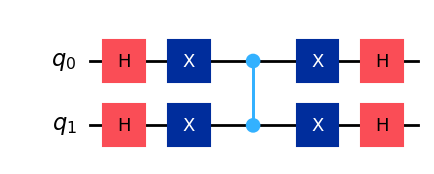

In [3]:
def grover_diffuser(n: int) -> QuantumCircuit:
    """Constructs the standard Grover diffuser for n qubits."""
    qc = QuantumCircuit(n, name="Diffuser")
    
    # Apply H gates
    qc.h(range(n))
    
    # Apply X gates
    qc.x(range(n))
    
    # Do multi-controlled-Z gate
    # For 2 qubits, this is just a standard CZ gate
    qc.cz(0, 1)
    
    # Apply X gates again
    qc.x(range(n))
    
    # Apply H gates again
    qc.h(range(n))
    
    return qc

# Visualize the Diffuser
print("Diffuser Circuit:")
display(grover_diffuser(2).draw('mpl'))

## Step 3: Full Algorithm & Execution

Now we put the pieces together:
1. Initialize the qubits in a uniform superposition using Hadamard gates.
2. Apply the Oracle.
3. Apply the Diffuser.
4. Measure the qubits.

We will run this on the `AerSimulator` and verify that the algorithm identifies the state `11` with near-100% probability.

Full Grover's Search Circuit:


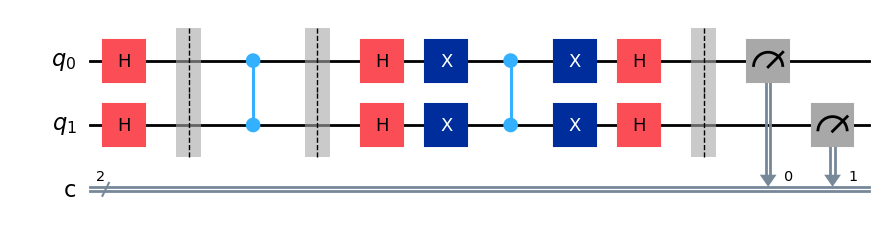


Search Output: {'11': 1024}


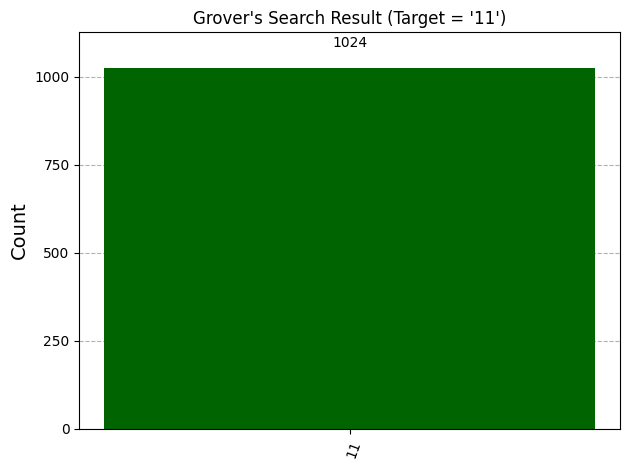

In [4]:
def run_grovers_2_qubit() -> QuantumCircuit:
    """Constructs and executes the full 2-qubit Grover's Search."""
    qc = QuantumCircuit(2, 2)
    
    # 1. Initialize superposition
    qc.h([0, 1])
    qc.barrier()
    
    # 2. Append Oracle
    oracle = grover_oracle_11()
    qc.compose(oracle, inplace=True)
    qc.barrier()
    
    # 3. Append Diffuser
    diffuser = grover_diffuser(2)
    qc.compose(diffuser, inplace=True)
    qc.barrier()
    
    # 4. Measure
    qc.measure([0, 1], [0, 1])
    
    return qc

# Build the complete circuit
grover_circuit = run_grovers_2_qubit()

# Display the full circuit architecture
print("Full Grover's Search Circuit:")
display(grover_circuit.draw('mpl'))

# Initialize the V2 Sampler and execute
sampler = StatevectorSampler()
job = sampler.run([grover_circuit], shots=1024)
pub_result = job.result()[0]

# Extract counts from the classical register 'c'
counts = pub_result.data.c.get_counts()

print(f"\nSearch Output: {counts}")

# Verify the 100% spike on the state '11'
display(plot_histogram(counts, title="Grover's Search Result (Target = '11')", color='darkgreen'))